# Lab 09: Monte Carlo Simulation

## Examples (by instructor)

In this lab, you'll practice Monte Carlo simulation from Chapter 14: sampling from input distributions, propagating uncertainty through a model, and summarizing the output distribution to estimate failure rates and reliability.

### Example 1: Estimating π with Monte Carlo

Throw $N$ random darts at a unit square. The fraction landing inside the quarter-circle estimates $\pi/4$.

N = 10,000  →  π estimate = 3.1420  (error = 0.0004)


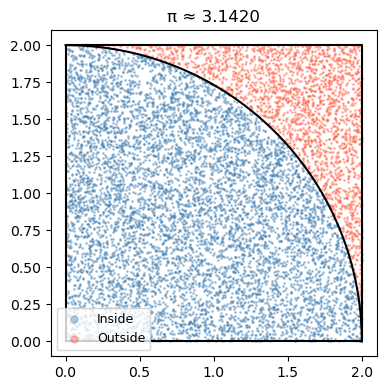

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(seed=0)
N   = 10_000
domain_scale = 2.0
x = rng.random(N)*domain_scale
y = rng.random(N)*domain_scale
inside = (x**2 + y**2) <= domain_scale**2

pi_est = 4 * np.sum(inside) / N
print(f"N = {N:,}  →  π estimate = {pi_est:.4f}  (error = {abs(pi_est - np.pi):.4f})")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x[inside],  y[inside],  s=1, color='steelblue', alpha=0.4, label='Inside')
ax.scatter(x[~inside], y[~inside], s=1, color='tomato',    alpha=0.4, label='Outside')
theta = np.linspace(0, np.pi/2, 300)
ax.plot(domain_scale * np.cos(theta), domain_scale * np.sin(theta), 'k-', linewidth=1.5)
# Square boundary
ax.plot([0, domain_scale, domain_scale, 0, 0],
        [0, 0, domain_scale, domain_scale, 0], 'k-', linewidth=1.5)
ax.set_aspect('equal'); ax.set_title(f'π ≈ {pi_est:.4f}'); ax.legend(markerscale=5, fontsize=9)
plt.tight_layout(); plt.show()

### Example 2: Process Reliability — Propagating Input Uncertainty

A reactor product must have **purity ≥ 97.5%**. Residence time $\tau \sim \mathcal{N}(120, 12^2)$ s and temperature $T \sim \mathcal{N}(400, 8^2)$ K vary each batch. The purity model is:

$$\text{Purity} = 100 \times \left(1 - 0.2\,e^{-k(T)\,\tau}\right), \qquad k(T) = e^{-1550/T}$$

Run 50,000 simulated batches and estimate the failure rate.

Mean purity   : 98.263 %
Std dev       : 0.546 %
Failure rate  : 9.14%  (purity < 97.5%)


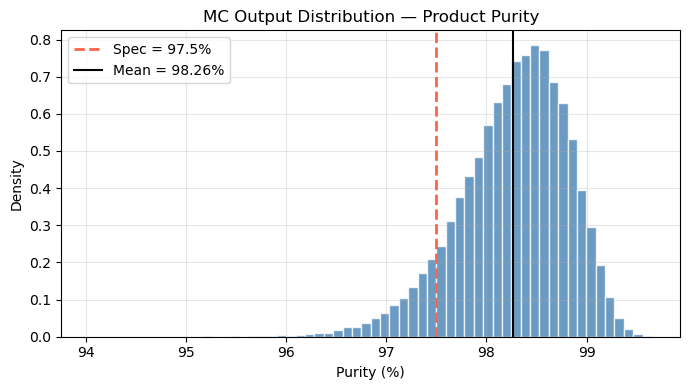

In [4]:
def purity_model(tau, T):
    k = np.exp(-1550.0 / T)
    return 100.0 * (1.0 - 0.2 * np.exp(-k * tau))

tau_mean, tau_std = 120.0, 12.0
T_mean,   T_std   = 400.0,  8.0
spec = 97.5

rng_mc = np.random.default_rng(seed=42)
N_mc   = 50_000

tau_mc = rng_mc.normal(tau_mean, tau_std, N_mc)
T_mc   = rng_mc.normal(T_mean,   T_std,   N_mc)
pur_mc = purity_model(tau_mc, T_mc)

print(f"Mean purity   : {np.mean(pur_mc):.3f} %")
print(f"Std dev       : {np.std(pur_mc, ddof=1):.3f} %")
print(f"Failure rate  : {np.mean(pur_mc < spec)*100:.2f}%  (purity < {spec}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pur_mc, bins=60, color='steelblue', edgecolor='white', density=True, alpha=0.8)
ax.axvline(spec, color='tomato', linestyle='--', linewidth=2, label=f'Spec = {spec}%')
ax.axvline(np.mean(pur_mc), color='black', linestyle='-', linewidth=1.5,
           label=f'Mean = {np.mean(pur_mc):.2f}%')
ax.set_xlabel('Purity (%)'); ax.set_ylabel('Density')
ax.set_title('MC Output Distribution — Product Purity')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Example 3: Convergence — How Many Samples Are Enough?

The MC estimate improves as $N$ grows. Error shrinks as $\sim 1/\sqrt{N}$. Track the running failure rate estimate as batches accumulate.

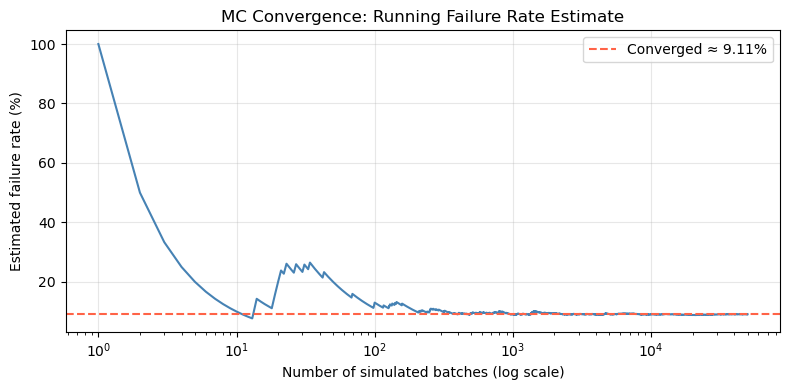

In [ ]:
rng_cv = np.random.default_rng(seed=7)
N_total = 50_000

tau_cv = rng_cv.normal(tau_mean, tau_std, N_total)
T_cv   = rng_cv.normal(T_mean,   T_std,   N_total)
pur_cv = purity_model(tau_cv, T_cv)

# Running failure rate at each step
running_fail = np.cumsum(pur_cv < spec) / np.arange(1, N_total + 1)
# np.cumsum --> cumulative sum of failures up to each point
# example: if pur_cv[0:5] = [98, 96, 97, 95, 99] and spec=97, then (pur_cv < spec) = [False, True, False, True, False]
# cumulative failures: [0, 1, 1, 2, 2]
# running_fail: [0/1, 1/2, 1/3, 2/4, 2/5] = [0.0, 0.5, 0.3333, 0.5, 0.4]

# alternatively, we could compute running_fail using a loop, but the cumulative sum approach is more efficient and concise.
# running_fail_loop = []
# failures = 0
# total = 0
# for pur in pur_cv:
#     if pur < spec:
#         failures += 1
#     total += 1
#     running_fail_loop.append(failures / total)
    

fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(np.arange(1, N_total + 1), running_fail * 100, color='steelblue', linewidth=1.5)
ax.semilogx(np.arange(1, N_total + 1), running_fail * 100, color='steelblue', linewidth=1.5)
ax.axhline(running_fail[-1] * 100, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Converged ≈ {running_fail[-1]*100:.2f}%')
ax.set_xlabel('Number of simulated batches (log scale)')
ax.set_ylabel('Estimated failure rate (%)')
ax.set_title('MC Convergence: Running Failure Rate Estimate')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## Warm-Up: Syntax Practice

Short exercises to get comfortable with the MC building blocks before the main problems.

**Exercise 1 — Sample from a distribution.**

Using `np.random.default_rng(seed=10)`, draw 1,000 samples from $\mathcal{N}(\mu=500,\; \sigma=20)$. Print the sample mean and std. Then print the fraction of samples exceeding 530.

In [5]:
import numpy as np

rng = np.random.default_rng(seed=10)

samples = rng.normal(500, 20, 1000)

print(f"Sample mean : {np.mean(samples):.2f}")
print(f"Sample std  : {np.std(samples, ddof=1):.2f}")
print(f"Fraction > 530 : {np.mean(samples > 530):.4f}")

Sample mean : 498.62
Sample std  : 19.90
Fraction > 530 : 0.0550


**Exercise 2 — Pass a sample through a model.**

Feed concentration $C_0 \sim \mathcal{N}(2.0,\; 0.1^2)$ mol/L. After a first-order reaction with fixed $k=0.5$ min⁻¹ and $t=3$ min, the outlet concentration is:

$$C = C_0 \cdot e^{-k\,t}$$

Using `seed=5` and $N=5{,}000$ samples, compute the mean and std of $C$. Print what fraction of outlet concentrations fall below 0.25 mol/L.

In [32]:
import numpy as np

k, t = 0.5, 3.0

rng = np.random.default_rng(seed=5)
C0  = rng.normal(2.0, 0.1, 5000)

C_out = C0 * np.exp(-k * t)

print(f"Mean C_out : {np.mean(C_out):.4f} mol/L")
print(f"Std  C_out : {np.std(C_out, ddof=1):.4f} mol/L")
print(f"Fraction below 0.25 mol/L : {np.mean(C_out < 0.25):.4f}")

Mean C_out : 0.4470 mol/L
Std  C_out : 0.0224 mol/L
Fraction below 0.25 mol/L : 0.0000


**Exercise 3 — Two uncertain inputs.**

Both $k \sim \mathcal{N}(0.5,\; 0.05^2)$ and $t \sim \mathcal{N}(3.0,\; 0.2^2)$ are uncertain (with fixed $C_0 = 2.0$ mol/L). Using `seed=8` and $N=10{,}000$, sample both, compute $C = C_0\,e^{-k\,t}$, and print mean, std, and fraction below 0.25 mol/L. Compare your answer to Exercise 2 — does uncertainty in $k$ and $t$ increase or decrease the spread?

In [33]:
import numpy as np

C0 = 2.0

rng = np.random.default_rng(seed=8)
k_s = rng.normal(0.5, 0.05, 10000)
t_s = rng.normal(3.0, 0.2,  10000)

C_out2 = C0 * np.exp(-k_s * t_s)

print(f"Mean C_out : {np.mean(C_out2):.4f} mol/L")
print(f"Std  C_out : {np.std(C_out2, ddof=1):.4f} mol/L")
print(f"Fraction below 0.25 mol/L : {np.mean(C_out2 < 0.25):.4f}")

Mean C_out : 0.4534 mol/L
Std  C_out : 0.0816 mol/L
Fraction below 0.25 mol/L : 0.0014


**Exercise 4 — Summarize output distribution.**

Using the `C_out2` array from Exercise 3, print the 5th and 95th percentiles and plot a histogram with a vertical line at the 5th percentile.

5th  percentile : 0.3279 mol/L
95th percentile : 0.5935 mol/L


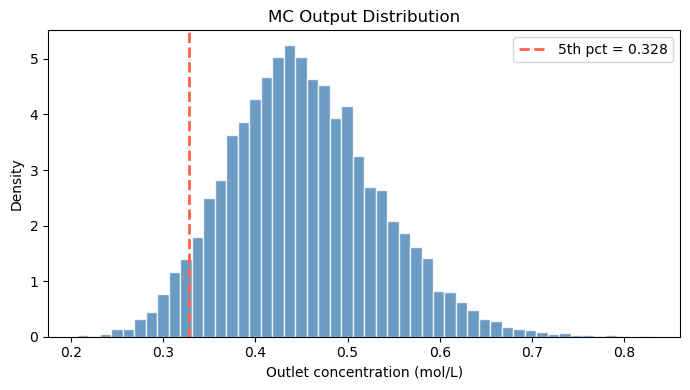

In [8]:
import numpy as np
import matplotlib.pyplot as plt

p5  = np.percentile(C_out2, 5)
p95 = np.percentile(C_out2, 95)

print(f"5th  percentile : {p5:.4f} mol/L")
print(f"95th percentile : {p95:.4f} mol/L")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(C_out2, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
ax.axvline(p5, color='tomato', linestyle='--', linewidth=2, label=f'5th pct = {p5:.3f}')
ax.set_xlabel('Outlet concentration (mol/L)')
ax.set_ylabel('Density')
ax.set_title('MC Output Distribution')
ax.legend()
plt.tight_layout()
plt.show()

---

## Practice Problems (by students)

### Problem 1: Heat Exchanger — Outlet Temperature Reliability

A shell-and-tube heat exchanger heats a process stream. The outlet temperature is modeled as:

$$T_\text{out} = T_\text{in} + \frac{U \cdot A \cdot \Delta T_{lm}}{\dot{m} \cdot C_p}$$

For simplicity, use the linearized form:

$$T_\text{out} = T_\text{in} + \eta \cdot (T_\text{hot} - T_\text{in})$$

where $\eta$ is the heat exchanger effectiveness. The following inputs are uncertain each day:

| Variable | Symbol | Distribution |
|----------|--------|-------------|
| Inlet temperature (°C) | $T_\text{in}$ | $\mathcal{N}(25,\; 3^2)$ |
| Hot side temperature (°C) | $T_\text{hot}$ | $\mathcal{N}(120,\; 5^2)$ |
| Effectiveness | $\eta$ | $\mathcal{N}(0.75,\; 0.04^2)$ |

The process requires $T_\text{out} \geq 80°C$.

**(a)** Using `seed=15` and $N = 50{,}000$ samples, simulate $T_\text{out}$ for all three uncertain inputs. Print mean, std, 5th percentile, and the failure rate (% of days below 80°C).

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- Model ---
def T_out_model(T_in, T_hot, eta):
    return T_in + eta * (T_hot - T_in)

spec = 80.0
N = 50_000

# (a) All three inputs uncertain
rng = np.random.default_rng(seed=15)
T_in  = rng.normal(25,   3,    N)
T_hot = rng.normal(120,  5,    N)
eta   = rng.normal(0.75, 0.04, N)

T_out = T_out_model(T_in, T_hot, eta)

mean_T  = np.mean(T_out)
std_T   = np.std(T_out, ddof=1)
p5_T    = np.percentile(T_out, 5)
fail_rate = np.mean(T_out < spec) * 100

print("=== Part (a) ===")
print(f"Mean T_out        : {mean_T:.2f} °C")
print(f"Std  T_out        : {std_T:.2f} °C")
print(f"5th percentile    : {p5_T:.2f} °C")
print(f"Failure rate      : {fail_rate:.2f}%  (T_out < {spec}°C)")


=== Part (a) ===
Mean T_out        : 96.30 °C
Std  T_out        : 5.40 °C
5th percentile    : 87.49 °C
Failure rate      : 0.08%  (T_out < 80.0°C)


**(b)** Plot the output histogram with vertical lines at the spec limit (80°C) and the mean.

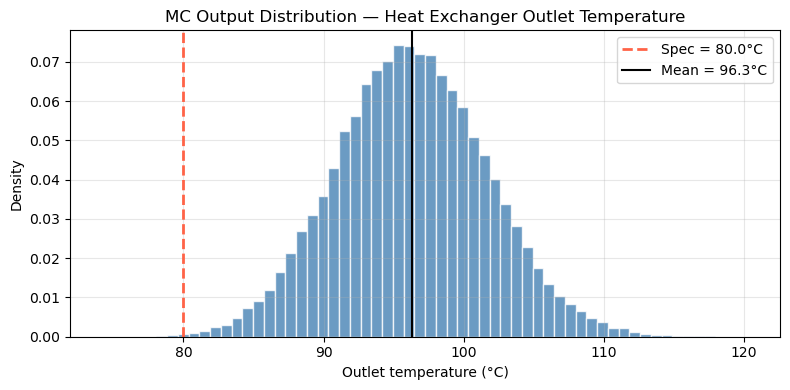

In [26]:
# (b) Histogram with spec line and shaded failing region
fig, ax = plt.subplots(figsize=(8, 4))
counts, bins, patches = ax.hist(T_out, bins=60, color='steelblue',
                                 edgecolor='white', density=True, alpha=0.8)
# # Shade failing bins (below spec)
# for patch, left in zip(patches, bins[:-1]):
#     if left < spec:
#         patch.set_facecolor('tomato')
#         patch.set_alpha(0.7)

ax.axvline(spec,   color='tomato', linestyle='--', linewidth=2,
           label=f'Spec = {spec}°C')
ax.axvline(mean_T, color='black',  linestyle='-',  linewidth=1.5,
           label=f'Mean = {mean_T:.1f}°C')
ax.set_xlabel('Outlet temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('MC Output Distribution — Heat Exchanger Outlet Temperature')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**(c)** Which input contributes most to variability? Re-run the simulation three times, each time holding **two inputs fixed at their means** and only sampling the third. Print the std of $T_\text{out}$ for each case and identify the most influential input.

In [16]:
# (c) One-at-a-time sensitivity
rng2 = np.random.default_rng(seed=15)
T_in_s  = rng2.normal(25,   3,    N)
T_hot_s = rng2.normal(120,  5,    N)
eta_s   = rng2.normal(0.75, 0.04, N)

# Only T_in varies
T_out_Tin  = T_out_model(T_in_s,  120,     0.75)
# Only T_hot varies
T_out_Thot = T_out_model(25,      T_hot_s, 0.75)
# Only eta varies
T_out_eta  = T_out_model(25,      120,     eta_s)

std_Tin  = np.std(T_out_Tin,  ddof=1)
std_Thot = np.std(T_out_Thot, ddof=1)
std_eta  = np.std(T_out_eta,  ddof=1)

stds = {'T_in': std_Tin, 'T_hot': std_Thot, 'eta': std_eta}
most_influential = max(stds, key=stds.get)

print("\n=== Part (c): One-at-a-time sensitivity ===")
print(f"Std when only T_in  varies : {std_Tin:.3f} °C")
print(f"Std when only T_hot varies : {std_Thot:.3f} °C")
print(f"Std when only eta   varies : {std_eta:.3f} °C")
print(f"→ '{most_influential}' contributes most to T_out variability.")


=== Part (c): One-at-a-time sensitivity ===
Std when only T_in  varies : 0.751 °C
Std when only T_hot varies : 3.731 °C
Std when only eta   varies : 3.807 °C
→ 'eta' contributes most to T_out variability.


### Problem 2: Batch Reactor Yield — Operating Condition Optimization

A batch reactor produces a polymer. The yield (%) is modeled as:

$$Y = 100 \times \left(1 - e^{-k(T)\,\tau}\right), \qquad k(T) = A\,e^{-E_a/(R\,T)}$$

with $A = 2\times10^6$ min⁻¹, $E_a/R = 6{,}000$ K, and the following uncertain operating conditions:

| Variable | Symbol | Baseline | Std dev |
|----------|--------|---------|---------|
| Residence time (min) | $\tau$ | 30 | 3 |
| Temperature (K) | $T$ | 370 | 10 |

The minimum acceptable yield is **85%**.

**(a)** Using `seed=99` and $N=50{,}000$, simulate the yield distribution at the baseline conditions. Print mean, std, and failure rate.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --- Model ---
A   = 2e6        # min^-1
EaR = 6000.0     # K  (Ea/R)
spec = 85.0      # % minimum yield

def yield_model(tau, T):
    k = A * np.exp(-EaR / T)
    return 100.0 * (1.0 - np.exp(-k * tau))

N = 50_000

# (a) Baseline: tau~N(30,3), T~N(370,10)
rng = np.random.default_rng(seed=99)
tau_a = rng.normal(30, 3,  N)
T_a   = rng.normal(370, 10, N)
Y_a   = yield_model(tau_a, T_a)

fail_a = np.mean(Y_a < spec) * 100
print("=== Part (a): Baseline ===")
print(f"Mean yield   : {np.mean(Y_a):.2f} %")
print(f"Std  yield   : {np.std(Y_a, ddof=1):.2f} %")
print(f"Failure rate : {fail_a:.2f}%")

=== Part (a): Baseline ===
Mean yield   : 98.18 %
Std  yield   : 3.52 %
Failure rate : 1.56%


**(b)** The process engineer proposes raising the mean temperature to 380 K (same std = 10 K). Re-run the simulation with this change. By how many percentage points does the failure rate drop?


In [20]:
# (b) Higher mean T: T~N(380,10)
rng_b = np.random.default_rng(seed=99)
tau_b = rng_b.normal(30, 3,  N)
T_b   = rng_b.normal(380, 10, N)
Y_b   = yield_model(tau_b, T_b)

fail_b = np.mean(Y_b < spec) * 100
print("\n=== Part (b): Higher mean T = 380 K ===")
print(f"Failure rate : {fail_b:.2f}%")
print(f"Reduction    : {fail_a - fail_b:.2f} percentage points")


=== Part (b): Higher mean T = 380 K ===
Failure rate : 0.09%
Reduction    : 1.47 percentage points


**(c)** Alternatively, the engineer could **tighten temperature control** to $\sigma_T = 5$ K (keeping mean at 370 K). Re-run this scenario. Compare the failure rate to part (b) — which strategy is more effective?

In [21]:
# (c) Tighter sigma_T: T~N(370,5)
rng_c = np.random.default_rng(seed=99)
tau_c = rng_c.normal(30, 3, N)
T_c   = rng_c.normal(370, 5, N)
Y_c   = yield_model(tau_c, T_c)

fail_c = np.mean(Y_c < spec) * 100
print("\n=== Part (c): Tighter control sigma_T = 5 K ===")
print(f"Failure rate : {fail_c:.2f}%")
print(f"Reduction vs baseline : {fail_a - fail_c:.2f} pp")
if fail_b < fail_c:
    print("→ Raising mean T (b) is more effective than tightening sigma_T (c).")
else:
    print("→ Tightening sigma_T (c) is more effective than raising mean T (b).")



=== Part (c): Tighter control sigma_T = 5 K ===
Failure rate : 0.00%
Reduction vs baseline : 1.56 pp
→ Tightening sigma_T (c) is more effective than raising mean T (b).


**(d)** Plot all three yield distributions (baseline, higher $T$, tighter $\sigma_T$) on a single histogram. Add a vertical line at 85%. Which scenario best shifts the distribution away from the spec limit?

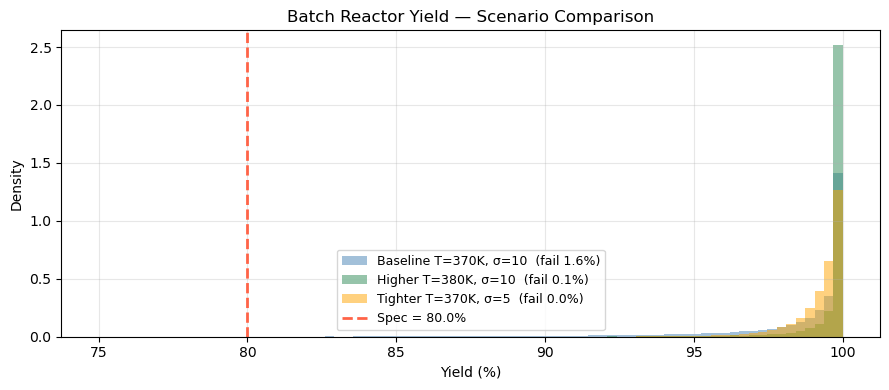

In [28]:
# (d) Overlaid histograms
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(75, 100, 80) #np.linspace(Y_a.min() - 1, 100, 80)
ax.hist(Y_a, bins=bins, density=True, alpha=0.5, color='steelblue',
        label=f'Baseline T=370K, σ=10  (fail {fail_a:.1f}%)')
ax.hist(Y_b, bins=bins, density=True, alpha=0.5, color='seagreen',
        label=f'Higher T=380K, σ=10  (fail {fail_b:.1f}%)')
ax.hist(Y_c, bins=bins, density=True, alpha=0.5, color='orange',
        label=f'Tighter T=370K, σ=5  (fail {fail_c:.1f}%)')
ax.axvline(spec, color='tomato', linestyle='--', linewidth=2, label=f'Spec = {spec}%')
ax.set_xlabel('Yield (%)')
ax.set_ylabel('Density')
ax.set_title('Batch Reactor Yield — Scenario Comparison')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()